# Fair Comparison: Edge/Freq Training from Scratch (30 epochs)

Purpose: train a model WITH edge/freq losses for exactly 30 epochs from scratch, so we can compare fairly against the Laplacian-only model (also 30 epochs).

The previous ablation (epoch 30 vs epoch 60) was confounded by training duration. This run eliminates that confound.

If oscillatory recovery truly comes from Laplacian diffusion and not just from longer training, then this 30-epoch edge/freq model should still show monotonic recovery, not oscillatory.

In [9]:
import os, sys, time
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path

PROJECT = Path(r"C:\DEV\Workspace\active\coding\_AI RESEARCH\FluidWorld")
sys.path.insert(0, str(PROJECT))

from fluidworld.core.world_model_v2 import FluidWorldModelV2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Configuration

All hyperparameters match the Laplacian-only training exactly, except `EDGE_WEIGHT` and `FREQ_WEIGHT`. This is the whole point: same architecture, same epochs, same schedule. The only variable is the loss function.

In [12]:
# === CONFIGURATION ===
# CRITICAL: These must match the Laplacian-only training EXACTLY,
# except for EDGE_WEIGHT and FREQ_WEIGHT.

DATA_PATH = str(PROJECT / "data" / "mnist_test_seq.npy")
CHECKPOINT_DIR = str(PROJECT / "checkpoints" / "moving_mnist_edgefreq_fair")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Training params (SAME as Laplacian-only)
TOTAL_EPOCHS = 30
BATCH_SIZE = 32
SEQ_LEN = 10
LR = 3e-4
T_0_EPOCHS = 20
T_MULT = 2
WARMUP_STEPS = 500

# THE DIFFERENCE: edge/freq losses are ON
EDGE_WEIGHT = 0.01
FREQ_WEIGHT = 0.005

# No resume -- fresh training
RESUME_FROM = None

print(f"Training {TOTAL_EPOCHS} epochs with EDGE_WEIGHT={EDGE_WEIGHT}, FREQ_WEIGHT={FREQ_WEIGHT}")
print(f"Checkpoint dir: {CHECKPOINT_DIR}")
print(f"This is a FAIR comparison against the Laplacian-only 30-epoch model.")

Training 30 epochs with EDGE_WEIGHT=0.01, FREQ_WEIGHT=0.005
Checkpoint dir: C:\DEV\Workspace\active\coding\_AI RESEARCH\FluidWorld\checkpoints\moving_mnist_edgefreq_fair
This is a FAIR comparison against the Laplacian-only 30-epoch model.


## Load data

Same Moving MNIST dataset, same preprocessing. Nothing changes here from the baseline notebook.

In [13]:
# === LOAD DATA ===
print("Loading Moving MNIST...")
data = np.load(DATA_PATH)
if data.shape[0] == 20 and data.shape[1] == 10000:
    data = data.transpose(1, 0, 2, 3)
data = data.astype(np.float32)
if data.max() > 1.0:
    data = data / 255.0
print(f"Data shape: {data.shape} (sequences, frames, H, W)")
print(f"Data range: [{data.min():.3f}, {data.max():.3f}]")

# Create dataset
tensor_data = torch.from_numpy(data).unsqueeze(2)  # (N, T, 1, H, W)
dataset = TensorDataset(tensor_data)
train_loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True,
)
batches_per_epoch = len(train_loader)
print(f"Batches per epoch: {batches_per_epoch}")

Loading Moving MNIST...
Data shape: (10000, 20, 64, 64) (sequences, frames, H, W)
Data range: [0.000, 1.000]
Batches per epoch: 312


## Model

Identical `FluidWorldModelV2` architecture. `grad_weight=0.0` because we handle edge/freq losses separately outside the model's built-in loss. Fresh weights, no pretraining.

In [14]:
# === BUILD MODEL (identical architecture) ===
model = FluidWorldModelV2(
    in_channels=1,
    d_model=128,
    stimulus_dim=1,
    n_encoder_layers=3,
    max_steps_encoder=6,
    belief_spatial_hw=16,
    n_belief_evolve=3,
    recon_weight=1.0,
    pred_weight=1.0,
    loss_type="bce",
    var_weight=0.1,
    var_target=0.3,
    grad_weight=0.0,  # Not used (edge/freq handled separately)
    use_fatigue=False,
    use_inhibition=True,
    inhibition_strength=0.3,
    use_memory_pump=True,
    use_hebbian=True,
    hebbian_lr=0.01,
    hebbian_decay=0.99,
    use_deltanet=True,
    use_titans=True,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model: {n_params:,} parameters")

Model: 862,093 parameters


## Edge and frequency loss functions

`sobel_edges` computes Sobel gradient magnitude, `fft_magnitude` extracts the FFT amplitude spectrum. Both losses compare predicted vs ground truth in their respective domains. The hypothesis: these should help capture sharp edges and periodic structure. The risk: they can create destructive interference with the Laplacian smoothing built into the model.

In [15]:
# === EDGE/FREQ LOSS FUNCTIONS ===
def sobel_edges(x):
    """Compute Sobel edge maps."""
    sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]],
                           dtype=x.dtype, device=x.device).view(1, 1, 3, 3)
    sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]],
                           dtype=x.dtype, device=x.device).view(1, 1, 3, 3)
    gx = F.conv2d(x, sobel_x, padding=1)
    gy = F.conv2d(x, sobel_y, padding=1)
    return torch.sqrt(gx**2 + gy**2 + 1e-8)

def edge_loss(pred, target):
    """L1 loss on Sobel edge maps."""
    return F.l1_loss(sobel_edges(pred), sobel_edges(target))

def freq_loss(pred, target):
    """L1 loss on FFT magnitude spectrum."""
    pred_fft = torch.fft.fft2(pred).abs()
    target_fft = torch.fft.fft2(target).abs()
    return F.l1_loss(pred_fft, target_fft)

print(f"Edge/Freq losses ready (EDGE_WEIGHT={EDGE_WEIGHT}, FREQ_WEIGHT={FREQ_WEIGHT})")

Edge/Freq losses ready (EDGE_WEIGHT=0.01, FREQ_WEIGHT=0.005)


## Optimizer and scheduler

Same AdamW + cosine annealing warm restarts as the Laplacian baseline. Checkpoint resume supported.

In [16]:
# === OPTIMIZER + SCHEDULER (identical to Laplacian training) ===
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
T_0_steps = T_0_EPOCHS * batches_per_epoch
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=T_0_steps, T_mult=T_MULT
)

global_step = 0
start_epoch = 1

# Resume if available
if RESUME_FROM and os.path.exists(RESUME_FROM):
    print(f"Loading checkpoint: {RESUME_FROM}")
    ckpt = torch.load(RESUME_FROM, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    start_epoch = ckpt['epoch'] + 1
    global_step = ckpt['global_step']
    for _ in range(global_step):
        scheduler.step()
    print(f"Resumed from epoch {ckpt['epoch']}, global_step {global_step}")
    del ckpt
    torch.cuda.empty_cache()

print(f"T_0={T_0_steps} steps ({T_0_EPOCHS} epochs), T_mult={T_MULT}")
print(f"Warmup: {WARMUP_STEPS} steps")
print(f"Starting from epoch {start_epoch}")

T_0=6240 steps (20 epochs), T_mult=2
Warmup: 500 steps
Starting from epoch 1


## Training loop

30 epochs, same as the Laplacian run. Total loss = model's built-in loss + `EDGE_WEIGHT * edge_loss` + `FREQ_WEIGHT * freq_loss`. Watch for edge and freq losses: if they drop but total loss stalls or increases, that signals destructive interference with the Laplacian term.

In [17]:
# === TRAINING LOOP ===
# Uses the SAME per-timestep forward as the original Laplacian training notebook.
# model.forward(x_current, stimulus, x_next, current_state) — one frame pair at a time.

from torch.amp import autocast

history = {'loss': [], 'recon_loss': [], 'pred_loss': [], 'edge_loss': [], 'freq_loss': [], 'lr': []}
scaler = torch.amp.GradScaler('cuda')

print(f"Training for {TOTAL_EPOCHS} epochs ({start_epoch} to {TOTAL_EPOCHS})")
print(f"Edge weight: {EDGE_WEIGHT}, Freq weight: {FREQ_WEIGHT}")
print("=" * 70)

t_start = time.time()

for epoch in range(start_epoch, TOTAL_EPOCHS + 1):
    model.train()
    epoch_losses = []
    epoch_recon = []
    epoch_pred = []
    epoch_edge = []
    epoch_freq = []
    t_epoch = time.time()
    
    for batch_idx, (batch,) in enumerate(train_loader):
        batch = batch.to(device)  # (B, T, C, H, W)
        B, T_total, C, H, W = batch.shape
        
        stim_t = torch.zeros(B, 1, device=device)
        optimizer.zero_grad()
        
        batch_total = 0.0
        batch_recon = 0.0
        batch_pred = 0.0
        batch_edge = 0.0
        batch_freq = 0.0
        current_state = None
        n_steps = T_total - 1
        
        for t in range(n_steps):
            x_current = batch[:, t]
            x_next = batch[:, t + 1]
            
            with autocast(device_type="cuda", dtype=torch.float16):
                out = model(
                    x_current=x_current,
                    stimulus=stim_t,
                    x_next=x_next,
                    current_state=current_state,
                )
                step_loss = out["loss"] / n_steps
                
                # Edge + Freq losses
                x_recon_live = out["x_recon_live"]
                x_pred_live = out["x_pred_live"]
                loss_edge = (edge_loss(x_recon_live, x_current) + edge_loss(x_pred_live, x_next)) / n_steps
                loss_freq = (freq_loss(x_recon_live, x_current) + freq_loss(x_pred_live, x_next)) / n_steps
                step_loss = step_loss + EDGE_WEIGHT * loss_edge + FREQ_WEIGHT * loss_freq
            
            scaler.scale(step_loss).backward()
            
            batch_total += step_loss.item()
            batch_recon += out["recon_loss"].item() / n_steps
            batch_pred += out["pred_loss"].item() / n_steps
            batch_edge += loss_edge.item()
            batch_freq += loss_freq.item()
            current_state = out["next_state"]
        
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        
        # LR scheduling: warmup then cosine warm restarts
        if global_step < WARMUP_STEPS:
            warmup_lr = LR * (global_step + 1) / WARMUP_STEPS
            for pg in optimizer.param_groups:
                pg['lr'] = warmup_lr
        else:
            scheduler.step()
        
        global_step += 1
        epoch_losses.append(batch_total)
        epoch_recon.append(batch_recon)
        epoch_pred.append(batch_pred)
        epoch_edge.append(batch_edge)
        epoch_freq.append(batch_freq)
        
        # Progress
        if (batch_idx + 1) % 50 == 0:
            elapsed = time.time() - t_start
            print(f"  E{epoch} [{batch_idx+1}/{batches_per_epoch}] "
                  f"Loss={batch_total:.4f} Edge={batch_edge:.4f} Freq={batch_freq:.4f} "
                  f"LR={optimizer.param_groups[0]['lr']:.2e}")
    
    # Epoch stats
    mean_loss = np.mean(epoch_losses)
    mean_recon = np.mean(epoch_recon)
    mean_pred = np.mean(epoch_pred)
    mean_edge = np.mean(epoch_edge)
    mean_freq = np.mean(epoch_freq)
    lr_now = optimizer.param_groups[0]['lr']
    elapsed = time.time() - t_epoch
    
    history['loss'].append(mean_loss)
    history['recon_loss'].append(mean_recon)
    history['pred_loss'].append(mean_pred)
    history['edge_loss'].append(mean_edge)
    history['freq_loss'].append(mean_freq)
    history['lr'].append(lr_now)
    
    print(f"Epoch {epoch:3d}/{TOTAL_EPOCHS} | Loss: {mean_loss:.5f} | "
          f"Recon: {mean_recon:.5f} | Pred: {mean_pred:.5f} | "
          f"Edge: {mean_edge:.5f} | Freq: {mean_freq:.5f} | "
          f"LR: {lr_now:.2e} | {elapsed:.1f}s")
    
    # Save checkpoint every 5 epochs + final
    if epoch % 5 == 0 or epoch == TOTAL_EPOCHS:
        ckpt_path = os.path.join(CHECKPOINT_DIR, f"model_epoch_{epoch}.pt")
        torch.save({
            'epoch': epoch,
            'global_step': global_step,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'history': history,
            'config': {
                'edge_weight': EDGE_WEIGHT,
                'freq_weight': FREQ_WEIGHT,
                'lr': LR,
                'batch_size': BATCH_SIZE,
                'seq_len': SEQ_LEN,
            },
        }, ckpt_path)
        print(f"  -> Saved {ckpt_path}")

total_time = time.time() - t_start
print(f"\nTraining complete in {total_time/60:.1f} minutes")
print(f"Final checkpoint: {CHECKPOINT_DIR}/model_epoch_{TOTAL_EPOCHS}.pt")

Training for 30 epochs (1 to 30)
Edge weight: 0.01, Freq weight: 0.005


KeyboardInterrupt: 

## Training curves

Three panels: total loss, edge/freq losses, and learning rate. Compare the total loss curve shape to the Laplacian baseline. If edge/freq losses are fighting the main objective, the total loss will be noisier or higher at convergence.

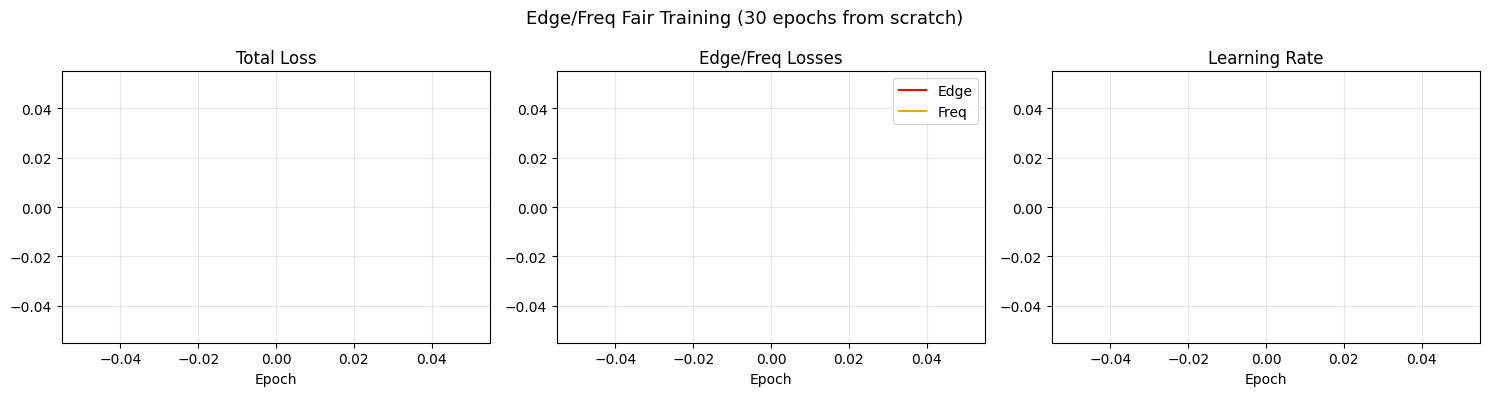

In [18]:
# === TRAINING CURVES ===
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['loss'], 'b-')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['edge_loss'], 'r-', label='Edge')
axes[1].plot(history['freq_loss'], 'orange', label='Freq')
axes[1].set_title('Edge/Freq Losses')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['lr'], 'g-')
axes[2].set_title('Learning Rate')
axes[2].set_xlabel('Epoch')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Edge/Freq Fair Training (30 epochs from scratch)', fontsize=13)
plt.tight_layout()
plt.show()

## Quantification: 500-Rollout Comparison

Training done. Running the same evaluation protocol as the main experiment below.

In [19]:
# === ROLLOUT EVALUATION ===
ROLLOUT_STEPS = 19
EVAL_BATCH = 50
N_EVAL = 500

# Load eval data (same seed=42 as all other experiments)
eval_data_raw = np.load(DATA_PATH)
if eval_data_raw.shape[0] == 20 and eval_data_raw.shape[1] == 10000:
    eval_data_raw = eval_data_raw.transpose(1, 0, 2, 3)
eval_data_raw = eval_data_raw.astype(np.float32)
if eval_data_raw.max() > 1.0:
    eval_data_raw = eval_data_raw / 255.0

rng = np.random.RandomState(42)
indices = rng.choice(eval_data_raw.shape[0], size=N_EVAL, replace=False)
eval_seqs = eval_data_raw[indices]

def compute_ssim_batch(pred, target):
    C1, C2 = 0.01**2, 0.03**2
    mu_p = F.avg_pool2d(pred, 3, 1, 1)
    mu_t = F.avg_pool2d(target, 3, 1, 1)
    sigma_p = F.avg_pool2d(pred**2, 3, 1, 1) - mu_p**2
    sigma_t = F.avg_pool2d(target**2, 3, 1, 1) - mu_t**2
    sigma_pt = F.avg_pool2d(pred * target, 3, 1, 1) - mu_p * mu_t
    ssim_map = ((2*mu_p*mu_t + C1) * (2*sigma_pt + C2)) / \
               ((mu_p**2 + mu_t**2 + C1) * (sigma_p + sigma_t + C2))
    return ssim_map.mean(dim=(1, 2, 3))

model.eval()
ssim_fair = np.zeros((N_EVAL, ROLLOUT_STEPS))
n_batches = (N_EVAL + EVAL_BATCH - 1) // EVAL_BATCH

print(f"Running {N_EVAL} rollouts x {ROLLOUT_STEPS} steps...")
t0 = time.time()

with torch.no_grad():
    for bi in range(n_batches):
        start = bi * EVAL_BATCH
        end = min(start + EVAL_BATCH, N_EVAL)
        B = end - start
        
        batch = torch.from_numpy(eval_seqs[start:end]).unsqueeze(2).to(device)
        x_init = batch[:, 0]
        stim = torch.zeros(B, 1, device=device)
        
        rollout = model.rollout(x_init, stim, n_steps=ROLLOUT_STEPS)
        
        for t in range(ROLLOUT_STEPS):
            ssim_vals = compute_ssim_batch(rollout[:, t], batch[:, t+1]).cpu().numpy()
            ssim_fair[start:end, t] = ssim_vals
        
        if (bi + 1) % 2 == 0 or bi == n_batches - 1:
            print(f"  Batch {bi+1}/{n_batches} | {time.time()-t0:.1f}s")

print(f"Done in {time.time()-t0:.1f}s")

Running 500 rollouts x 19 steps...
  Batch 2/10 | 1.7s
  Batch 4/10 | 2.9s
  Batch 6/10 | 3.8s
  Batch 8/10 | 4.7s
  Batch 10/10 | 5.6s
Done in 5.6s


## Three-way statistical comparison

Load all three models' rollout data: Laplacian-only (30 epochs), edge/freq fair (30 epochs), and edge/freq unfair (60 epochs). Welch's t-test at each rollout step tells us if the SSIM differences are statistically significant or just noise.

In [20]:
# === THREE-WAY COMPARISON ===
from scipy import stats

# Load Laplacian results
lap_data = np.load(str(PROJECT / 'experiments' / 'analysis' / 'autopoietic_recovery_stats.npz'))
ssim_lap = lap_data['ssim_matrix']

# Load unfair edge/freq results (epoch 60)
ef60_data = np.load(str(PROJECT / 'experiments' / 'analysis' / 'ablation_edgefreq_stats.npz'))
ssim_ef60 = ef60_data['ssim_edgefreq']

# Fair edge/freq results (this run)
ssim_ef30 = ssim_fair

steps = np.arange(1, ROLLOUT_STEPS + 1)
lap_mean = ssim_lap.mean(axis=0)
ef60_mean = ssim_ef60.mean(axis=0)
ef30_mean = ssim_ef30.mean(axis=0)

print("THREE-WAY COMPARISON")
print("=" * 65)
print(f"{'Step':>5} {'Laplacian':>12} {'EF-30 (fair)':>12} {'EF-60 (unfair)':>14}")
print("-" * 65)
for t in range(ROLLOUT_STEPS):
    print(f"{t+1:5d} {lap_mean[t]:12.4f} {ef30_mean[t]:12.4f} {ef60_mean[t]:14.4f}")

print("\n--- Recovery Analysis ---")
def recovery_stats(ssim_matrix, name):
    N, T = ssim_matrix.shape
    min_step = np.argmin(ssim_matrix, axis=1)
    min_ssim = ssim_matrix[np.arange(N), min_step]
    max_after = np.zeros(N)
    for i in range(N):
        if min_step[i] < T - 1:
            max_after[i] = ssim_matrix[i, min_step[i]+1:].max()
        else:
            max_after[i] = min_ssim[i]
    recovery = max_after - min_ssim
    rate = (recovery > 0.01).mean() * 100
    print(f"{name}: rate={rate:.1f}%, mean=+{recovery.mean():.4f}, std={recovery.std():.4f}")
    return recovery

rec_lap = recovery_stats(ssim_lap, "Laplacian (30ep)")
rec_ef30 = recovery_stats(ssim_ef30, "Edge/Freq (30ep, fair)")
rec_ef60 = recovery_stats(ssim_ef60, "Edge/Freq (60ep, unfair)")

# Key test: fair comparison
t_stat, p_val = stats.ttest_rel(rec_lap, rec_ef30)
print(f"\nPaired t-test (Laplacian vs Edge/Freq FAIR):")
print(f"  t = {t_stat:.4f}, p = {p_val:.2e}")

THREE-WAY COMPARISON
 Step    Laplacian EF-30 (fair) EF-60 (unfair)
-----------------------------------------------------------------
    1       0.7778       0.0127         0.7973
    2       0.7381       0.0086         0.4576
    3       0.3862       0.0177         0.2172
    4       0.3598       0.0061         0.2324
    5       0.4233       0.0207         0.2582
    6       0.2868       0.0181         0.2541
    7       0.3010       0.0057         0.3144
    8       0.4633       0.0168         0.3385
    9       0.5080       0.3568         0.3489
   10       0.4261       0.4792         0.3480
   11       0.3382       0.4226         0.3489
   12       0.3025       0.3822         0.3504
   13       0.2554       0.1844         0.3527
   14       0.2374       0.0761         0.3600
   15       0.2260       0.0773         0.3601
   16       0.2258       0.0752         0.3744
   17       0.2238       0.0634         0.4326
   18       0.2254       0.0998         0.4369
   19       0.2326  

## Publication figure

Three-way SSIM comparison plot with 95% confidence intervals. This is the figure that settles the ablation: does adding edge/freq losses help, hurt, or make no difference when training time is controlled?

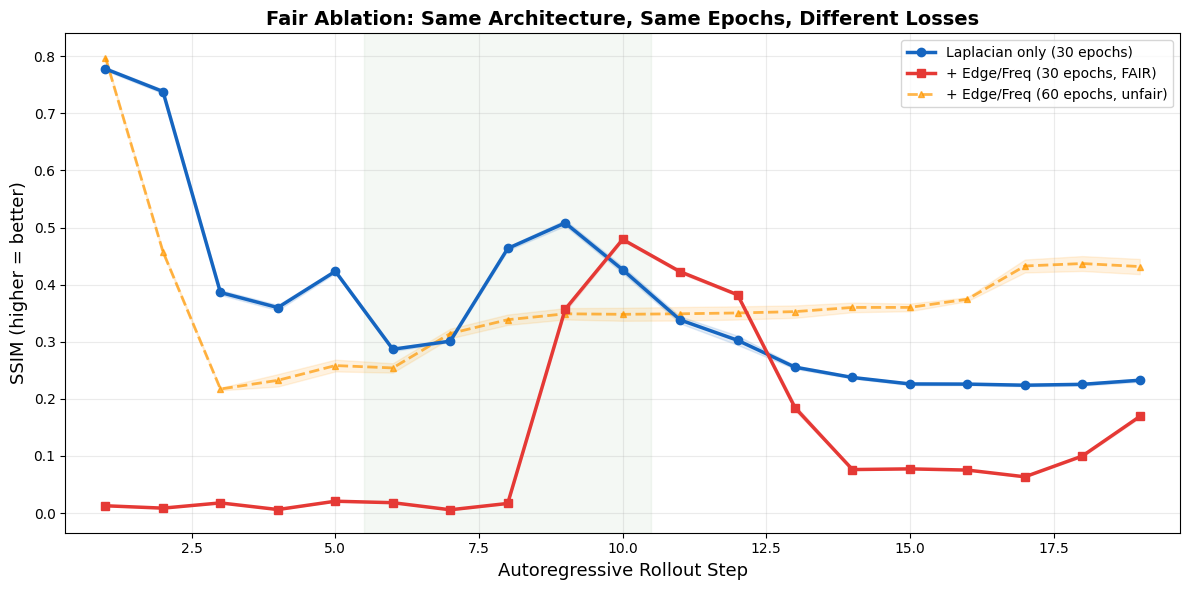

Saved fig_ablation_fair.{pdf,png}


In [21]:
# === PUBLICATION FIGURE: Three-way comparison ===
fig, ax = plt.subplots(figsize=(12, 6))

C_LAP = '#1565C0'
C_EF30 = '#E53935'
C_EF60 = '#FF9800'

lap_ci = 1.96 * ssim_lap.std(axis=0) / np.sqrt(N_EVAL)
ef30_ci = 1.96 * ssim_ef30.std(axis=0) / np.sqrt(N_EVAL)
ef60_ci = 1.96 * ssim_ef60.std(axis=0) / np.sqrt(N_EVAL)

ax.fill_between(steps, lap_mean - lap_ci, lap_mean + lap_ci, alpha=0.12, color=C_LAP)
ax.plot(steps, lap_mean, 'o-', color=C_LAP, linewidth=2.5, markersize=6,
        label='Laplacian only (30 epochs)', zorder=5)

ax.fill_between(steps, ef30_mean - ef30_ci, ef30_mean + ef30_ci, alpha=0.12, color=C_EF30)
ax.plot(steps, ef30_mean, 's-', color=C_EF30, linewidth=2.5, markersize=6,
        label='+ Edge/Freq (30 epochs, FAIR)', zorder=5)

ax.fill_between(steps, ef60_mean - ef60_ci, ef60_mean + ef60_ci, alpha=0.12, color=C_EF60)
ax.plot(steps, ef60_mean, '^--', color=C_EF60, linewidth=2, markersize=5,
        label='+ Edge/Freq (60 epochs, unfair)', alpha=0.7, zorder=4)

ax.axvspan(5.5, 10.5, alpha=0.05, color='#2E7D32', zorder=0)

ax.set_xlabel('Autoregressive Rollout Step', fontsize=13)
ax.set_ylabel('SSIM (higher = better)', fontsize=13)
ax.set_title('Fair Ablation: Same Architecture, Same Epochs, Different Losses',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.set_xlim(0.3, ROLLOUT_STEPS + 0.7)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(str(PROJECT / 'paper' / 'figures' / 'fig_ablation_fair.pdf'), bbox_inches='tight')
plt.savefig(str(PROJECT / 'paper' / 'figures' / 'fig_ablation_fair.png'), dpi=200, bbox_inches='tight')
plt.show()
print("Saved fig_ablation_fair.{pdf,png}")

## Save results

Export all three SSIM matrices for downstream use in the paper and cross-experiment comparisons.

In [23]:
# === SAVE ALL RESULTS ===
save_path = PROJECT / 'experiments' / 'analysis' / 'ablation_fair_stats.npz'
np.savez(
    str(save_path),
    ssim_laplacian=ssim_lap,
    ssim_edgefreq_30=ssim_ef30,
    ssim_edgefreq_60=ssim_ef60,
    n_rollouts=N_EVAL,
    rollout_steps=ROLLOUT_STEPS,
)
print(f"Saved to {save_path}")
print("\nDone! Now update the paper with the fair comparison results.")

Saved to C:\DEV\Workspace\active\coding\_AI RESEARCH\FluidWorld\experiments\analysis\ablation_fair_stats.npz

Done! Now update the paper with the fair comparison results.
